# A5 - Neural ODEs (NODE) on Ball-and-Beam: physical vs black-box

Notebook version of `node_ball_and_beam.py`.

Approach 2 of the A5 activity.  Ported from the course example
    https://helonayala.github.io/sysid/Pedagogical_example_NODE.html
and applied to the REAL ball-and-beam data (same inputs as A2/A3/A4:
experiment='multisine_05', resample_factor=50, y_dot_method='savgol').

State choice
------------
The ball-and-beam ball position behaves like a forced 2nd-order system, and
bab_datasets already provides a (Savitzky-Golay) velocity estimate y_dot, so
we use the measured state

    x = [ position (y), velocity (y_dot) ]

as the ground truth the ODE must reproduce (exactly like the pedagogical
example, whose state is [position, velocity]).

Two models (as requested)
-------------------------
  * PhysicsODE  - a physical 2nd-order model with 3 learnable parameters
                  (omega_n, zeta, gain).  This is the "modelo fisico (se
                  houver)": ball-and-beam does admit a simple 2nd-order form.
  * BlackBoxODE - a neural network dx/dt = f_theta(x, u).  We VARY the number
                  of states (n_states >= 2; the first 2 are the observed
                  [pos, vel], any extra ones are latent) and the network
                  architecture (hidden width).

Training (K-step rollout mini-batches - the "optional" part, included)
---------------------------------------------------------------------
Instead of integrating the whole record every step, each iteration samples a
mini-batch of short K-step windows (mini free-runs of K=20 samples) starting
at random points of the TRAIN half, integrates them with RK4 (torchdiffeq),
and matches the measured states.  This is much faster than full-trajectory
training and is exactly the scheme used on the reference page.

Normalisation
-------------
The black-box signals are min-max scaled to [0, 1] (train stats) for better
conditioning of the tanh network; R^2 is affine-invariant so the reported
numbers are unaffected, and everything is de-normalised for the plots.  The
physical model is trained in raw units so the derivative coupling
d(pos)/dt = vel stays physically consistent.

Requires:  torch, torchdiffeq, bab_datasets, scikit-learn
Run with:  python node_ball_and_beam.py

## Imports and setup

In [ ]:
import os

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint

HERE = os.path.abspath(os.path.dirname("__file__") or os.getcwd())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    import bab_datasets as nod
except ImportError as exc:  # pragma: no cover
    raise SystemExit(
        "The 'bab_datasets' package is required.\n"
        "    pip install --upgrade git+https://github.com/helonayala/bab_datasets.git"
    ) from exc

## Reproducibility + configuration

In [ ]:
RSEED = 42
np.random.seed(RSEED)
torch.manual_seed(RSEED)

EXPERIMENT = "multisine_05"
RESAMPLE_FACTOR = 50
Y_DOT_METHOD = "savgol"
TRAIN_FRACTION = 0.5

K_STEPS = 20          # mini free-run length (samples) per rollout
BATCH_SIZE = 128      # random initial conditions per iteration
EPOCHS_PHYS = 400
EPOCHS_BB = 400
LR_PHYS = 0.05
LR_BB = 0.01

# black-box sweep: (n_states, hidden_dim)
BB_GRID = [(2, 32), (2, 64), (3, 64)]

## Data loading

In [ ]:
def load_data():
    data = nod.load_experiment(
        EXPERIMENT, preprocess=True, plot=False, end_idx=None,
        resample_factor=RESAMPLE_FACTOR, zoom_last_n=10000,
        y_dot_method=Y_DOT_METHOD,
    )
    u = np.asarray(data.u, dtype=float).ravel()
    y = np.asarray(data.y, dtype=float).ravel()
    y_dot = np.asarray(data.y_dot, dtype=float).ravel()
    ts = float(data.sampling_time)
    return u, y, y_dot, ts

## ODE right-hand sides (shared linear input interpolation, from reference)

In [ ]:
class InputODE(nn.Module):
    """Base class holding the input series and doing linear u(t) interpolation."""

    def __init__(self):
        super().__init__()
        self.u_series = None          # (N, 1)
        self.t_series = None          # (N,)
        self.batch_start_times = None  # (batch, 1) absolute times, or None

    def u_at(self, t, x):
        if self.batch_start_times is not None:
            t_abs = self.batch_start_times + t
        else:
            t_abs = t * torch.ones_like(x[:, 0:1])
        k = torch.searchsorted(self.t_series, t_abs.reshape(-1), right=True)
        k = torch.clamp(k, 1, len(self.t_series) - 1)
        t1, t2 = self.t_series[k - 1].unsqueeze(1), self.t_series[k].unsqueeze(1)
        u1, u2 = self.u_series[k - 1], self.u_series[k]
        denom = (t2 - t1)
        denom[denom < 1e-6] = 1.0
        alpha = (t_abs - t1) / denom
        return u1 + alpha * (u2 - u1)

In [ ]:
class PhysicsODE(InputODE):
    """Forced 2nd-order system with learnable omega_n, zeta, gain (raw units)."""

    def __init__(self):
        super().__init__()
        self.log_wn = nn.Parameter(torch.tensor(1.0))
        self.log_zeta = nn.Parameter(torch.tensor(-1.0))
        self.log_gain = nn.Parameter(torch.tensor(0.0))

    def get_params(self):
        return (torch.exp(self.log_wn), torch.exp(self.log_zeta),
                torch.exp(self.log_gain))

    def forward(self, t, x):
        wn, zeta, gain = self.get_params()
        u_t = self.u_at(t, x)
        pos, vel = x[:, 0:1], x[:, 1:2]
        d_pos = vel
        d_vel = -2 * zeta * wn * vel - (wn ** 2) * pos + (gain * wn ** 2) * u_t
        return torch.cat([d_pos, d_vel], dim=1)

In [ ]:
class BlackBoxODE(InputODE):
    """Neural dx/dt = f(x, u); n_states >= 2, first 2 are observed [pos, vel]."""

    def __init__(self, n_states=2, hidden_dim=64):
        super().__init__()
        self.n_states = n_states
        self.net = nn.Sequential(
            nn.Linear(n_states + 1, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, n_states),
        )

    def forward(self, t, x):
        u_t = self.u_at(t, x)
        return self.net(torch.cat([x, u_t], dim=1))

## K-step rollout mini-batch training

In [ ]:
def train_model(model, name, Y_tensor, u_tensor, t_tensor, split,
                n_states, obs_dim=2, epochs=400, lr=0.01):
    print(f"\n--- Training {name} (n_states={n_states}) ---")
    model.to(device)
    model.u_series = u_tensor
    model.t_series = t_tensor
    optimizer = optim.Adam(model.parameters(), lr=lr)

    dt = (t_tensor[1] - t_tensor[0]).item()
    t_eval = torch.arange(0, K_STEPS * dt, dt, device=device)

    for epoch in range(epochs + 1):
        optimizer.zero_grad()
        # random K-step windows inside the TRAIN half only
        start_idx = np.random.randint(0, split - K_STEPS, size=BATCH_SIZE)

        x0 = torch.zeros(BATCH_SIZE, n_states, device=device)
        x0[:, :obs_dim] = Y_tensor[start_idx]        # extra latent states = 0
        model.batch_start_times = t_tensor[start_idx].reshape(-1, 1)

        pred = odeint(model, x0, t_eval, method="rk4")      # (K, batch, n_states)
        targets = torch.stack([Y_tensor[i:i + K_STEPS] for i in start_idx],
                              dim=1)                          # (K, batch, obs_dim)

        loss = torch.mean((pred[:, :, :obs_dim] - targets) ** 2)
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"  epoch {epoch:4d} | loss {loss.item():.6e}")
    return model

In [ ]:
def free_run_test(model, Y_tensor, t_tensor, split, n_states, obs_dim=2):
    """Simulate the whole TEST half from its first measured state."""
    model.eval()
    with torch.no_grad():
        x0 = torch.zeros(1, n_states, device=device)
        x0[:, :obs_dim] = Y_tensor[split:split + 1]
        model.batch_start_times = t_tensor[split].reshape(1, 1)
        t_rel = t_tensor[split:] - t_tensor[split]
        pred = odeint(model, x0, t_rel, method="rk4")   # (Ntest, 1, n_states)
    return pred.squeeze(1)[:, :obs_dim].cpu().numpy()   # (Ntest, obs_dim)

## Main

In [ ]:
u, y, y_dot, ts = load_data()
n = u.size
split = int(round(TRAIN_FRACTION * n))
t = np.arange(n) * ts

Y_raw = np.stack([y, y_dot], axis=1)                # (N, 2) measured state

print("=" * 74)
print(f"A5 NODE - Ball-and-Beam ('{EXPERIMENT}', Ts={ts:.3f}s)")
print(f"samples={n}  train={split}  test={n - split}  state=[pos, vel]")
print("=" * 74)

t_tensor = torch.tensor(t, dtype=torch.float32, device=device)
u_tensor = torch.tensor(u, dtype=torch.float32, device=device).reshape(-1, 1)
Yt_test = Y_raw[split:]                              # measured test states

results = []

### Physical model (raw units)

In [ ]:
Yraw_tensor = torch.tensor(Y_raw, dtype=torch.float32, device=device)
torch.manual_seed(RSEED)
phys = PhysicsODE()
phys = train_model(phys, "PhysicsODE", Yraw_tensor, u_tensor, t_tensor,
                   split, n_states=2, epochs=EPOCHS_PHYS, lr=LR_PHYS)
wn, zeta, gain = (p.item() for p in phys.get_params())
print(f"  identified: wn={wn:.3f}, zeta={zeta:.3f}, gain={gain:.3f}")
pred_phys = free_run_test(phys, Yraw_tensor, t_tensor, split, n_states=2)
r2_phys_pos = r2_score(Yt_test[:, 0], pred_phys[:, 0])
r2_phys_vel = r2_score(Yt_test[:, 1], pred_phys[:, 1])
results.append(("Physics (2 states)", pred_phys, r2_phys_pos, r2_phys_vel))
print(f"  free-run TEST R2: position={r2_phys_pos:.4f}  velocity={r2_phys_vel:.4f}")

### Black-box models (min-max [0,1] scaled)

In [ ]:
# scale each observed channel using TRAIN stats
lo = Y_raw[:split].min(axis=0)
hi = Y_raw[:split].max(axis=0)
rng = hi - lo
Y_scaled = (Y_raw - lo) / rng
u_lo, u_hi = float(u[:split].min()), float(u[:split].max())
u_scaled = (u - u_lo) / (u_hi - u_lo)
Ys_tensor = torch.tensor(Y_scaled, dtype=torch.float32, device=device)
us_tensor = torch.tensor(u_scaled, dtype=torch.float32, device=device).reshape(-1, 1)

best_bb = None
for (n_states, hidden) in BB_GRID:
    torch.manual_seed(RSEED)
    bb = BlackBoxODE(n_states=n_states, hidden_dim=hidden)
    name = f"BlackBox s={n_states} h={hidden}"
    bb = train_model(bb, name, Ys_tensor, us_tensor, t_tensor, split,
                     n_states=n_states, epochs=EPOCHS_BB, lr=LR_BB)
    pred_s = free_run_test(bb, Ys_tensor, t_tensor, split, n_states=n_states)
    # de-normalise the two observed channels back to physical units
    pred_bb = pred_s * rng + lo
    r2_pos = r2_score(Yt_test[:, 0], pred_bb[:, 0])
    r2_vel = r2_score(Yt_test[:, 1], pred_bb[:, 1])
    print(f"  free-run TEST R2: position={r2_pos:.4f}  velocity={r2_vel:.4f}")
    results.append((name, pred_bb, r2_pos, r2_vel))
    if best_bb is None or r2_pos > best_bb[2]:
        best_bb = (name, pred_bb, r2_pos, r2_vel)

### Summary table

In [ ]:
print("\n" + "=" * 74)
print(f"{'model':<26}{'R2 position':>14}{'R2 velocity':>14}")
print("-" * 74)
for name, _, r2p, r2v in results:
    print(f"{name:<26}{r2p:>14.4f}{r2v:>14.4f}")
print("=" * 74)

### Comparison figure (test half): measured vs phys vs best BB

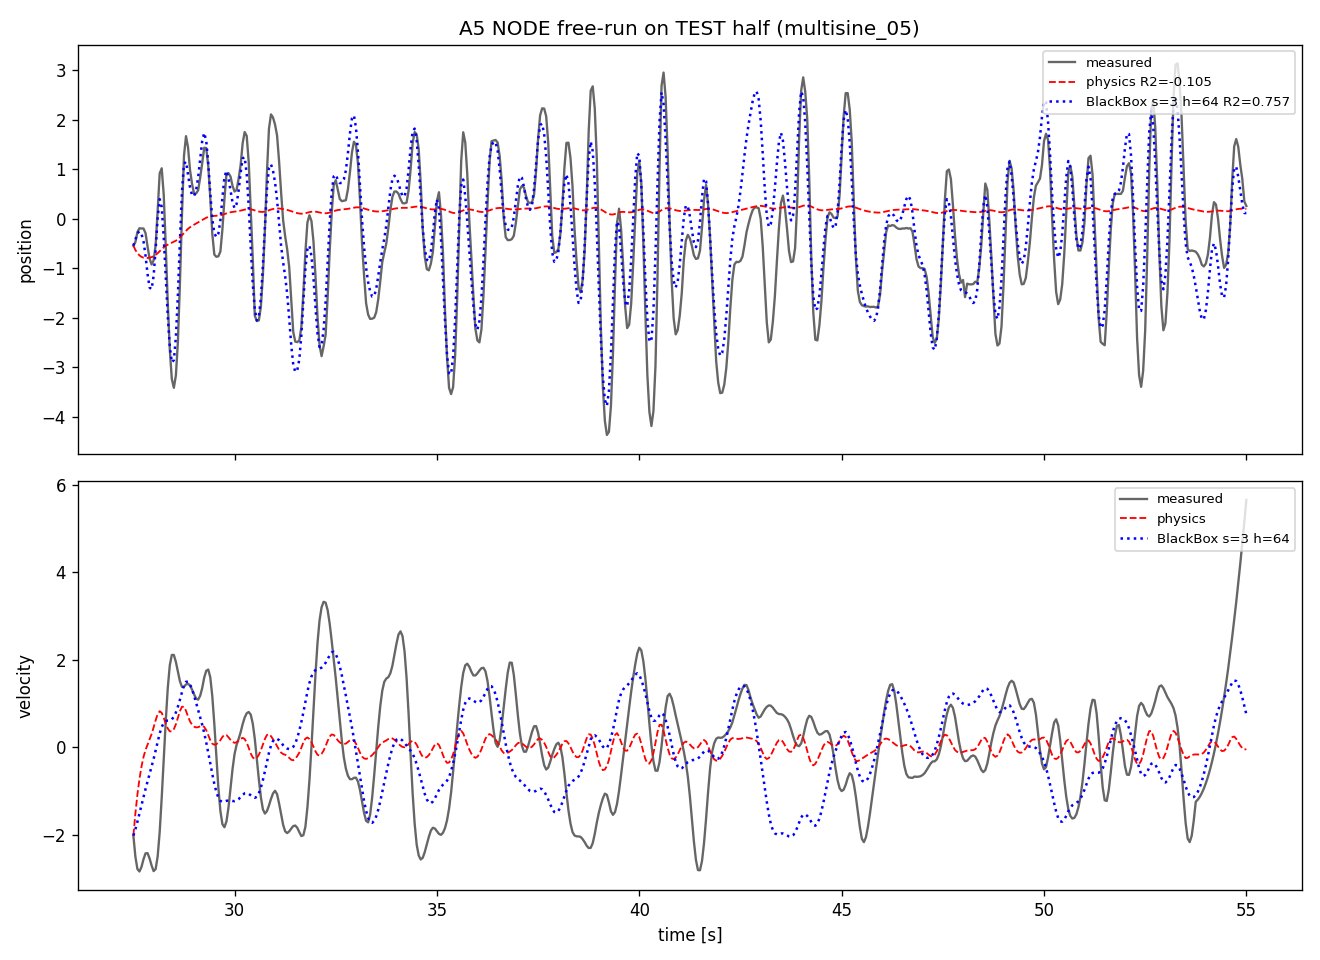

In [1]:
t_test = t[split:]
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
ax[0].plot(t_test, Yt_test[:, 0], "k", lw=1.4, alpha=0.6, label="measured")
ax[0].plot(t_test, results[0][1][:, 0], "r--", lw=1.1,
           label=f"physics R2={results[0][2]:.3f}")
ax[0].plot(t_test, best_bb[1][:, 0], "b:", lw=1.5,
           label=f"{best_bb[0]} R2={best_bb[2]:.3f}")
ax[0].set_ylabel("position")
ax[0].set_title(f"A5 NODE free-run on TEST half ({EXPERIMENT})")
ax[0].legend(loc="upper right", fontsize=8)

ax[1].plot(t_test, Yt_test[:, 1], "k", lw=1.4, alpha=0.6, label="measured")
ax[1].plot(t_test, results[0][1][:, 1], "r--", lw=1.1, label="physics")
ax[1].plot(t_test, best_bb[1][:, 1], "b:", lw=1.5, label=best_bb[0])
ax[1].set_ylabel("velocity")
ax[1].set_xlabel("time [s]")
ax[1].legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(HERE, "a5_node_comparison.png"), dpi=120)
print("\nSaved figure: a5_node_comparison.png")